In [1]:
# ============================================
# БЛОК 1: УСТАНОВКА И ПОДКЛЮЧЕНИЕ БИБЛИОТЕК
# ============================================
# Устанавливаем chDB — встраиваемый ClickHouse
# Устанавливаем клиент BigQuery для доступа к публичным данным
!pip install chdb --upgrade --quiet
!pip install google-cloud-bigquery --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.0/159.0 MB 6.5 MB/s eta 0:00:00


In [10]:
# Импортируем библиотеки
import chdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.cloud import bigquery
from google.colab import auth

# Настройка стилей графиков
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Все библиотеки загружены")
print(f"chDB version: {chdb.__version__}")

✅ Все библиотеки загружены
chDB version: 4.1.7


In [3]:
# Всё, что нужно для подключения к BigQuery
from google.colab import auth
from google.cloud import bigquery

auth.authenticate_user()
client = bigquery.Client(project="my-bigquery-project-496318")

print(f"✅ Готово. Проект: {client.project}")

✅ Готово. Проект: my-bigquery-project-496318


In [4]:
# ============================================
# БЛОК 2: ПРОСМОТР КОЛОНОК ПЕРЕД ВЫГРУЗКОЙ
# ============================================

# Шаг 1: Смотрим все колонки
query_columns = """
SELECT column_name, data_type
FROM `bigquery-public-data.iowa_liquor_sales.INFORMATION_SCHEMA.COLUMNS`
WHERE table_name = 'sales'
ORDER BY ordinal_position
"""

df_columns = client.query(query_columns).to_dataframe()
print("📋 КОЛОНКИ ТАБЛИЦЫ:")
for col in df_columns['column_name']:
    print(f"  - {col}")

print(f"\n✅ Всего колонок: {len(df_columns)}")
print("\n" + "="*60)

📋 КОЛОНКИ ТАБЛИЦЫ:
  - invoice_and_item_number
  - date
  - store_number
  - store_name
  - address
  - city
  - zip_code
  - store_location
  - county_number
  - county
  - category
  - category_name
  - vendor_number
  - vendor_name
  - item_number
  - item_description
  - pack
  - bottle_volume_ml
  - state_bottle_cost
  - state_bottle_retail
  - bottles_sold
  - sale_dollars
  - volume_sold_liters
  - volume_sold_gallons

✅ Всего колонок: 24



№	 Оригинал	       Перевод

1	 invoice_and_item_number	(номер_накладной_и_позиции)

2	 date	(дата)

3	 store_number	(номер_магазина)

4	 store_name	(название_магазина)

5	 address	(адрес)

6	 city	(город)

7	 zip_code	(почтовый_индекс)

8	 store_location	(геолокация_магазина)

9	 county_number	(номер_округа)

10	county	(округ)

11	category	(код_категории)

12	category_name	(название_категории)

13	vendor_number	(номер_поставщика)

14	vendor_name	(название_поставщика)

15	item_number	(номер_товара)

16	item_description	(описание_товара)

17	pack	(количество_в_упаковке)

18	bottle_volume_ml	(объём_бутылки_мл)

19	state_bottle_cost	(себестоимость)

20	state_bottle_retail	(розничная_цена)

21	bottles_sold	(продано_бутылок)

22	sale_dollars	(выручка_доллары)

23	volume_sold_liters	(объём_продаж_литры)

24	volume_sold_gallons	(объём_продаж_галлоны)

In [19]:
# ============================================
# БЛОК 2: ВЫГРУЗКА ДАННЫХ ИЗ BIGQUERY ЗА 2021-2023 ГОДЫ
# ============================================

print("🚀 НАЧАЛО ВЫГРУЗКИ ДАННЫХ")
print("⏱️ Это может занять несколько минут...")

# Запрос на выгрузку данных (выбираем нужные колонки)
query_full = """
SELECT
    date,               -- дата
    store_number,       -- номер_магазина
    city,               -- город
    category_name,      -- название_категории
    item_description,   -- описание_товара
    sale_dollars,       -- выручка_доллары
    bottles_sold,       -- продано_бутылок
    volume_sold_liters, -- объём_продаж_литры
    state_bottle_cost,  -- себестоимость
    state_bottle_retail,-- розничная_цена
    vendor_name,        -- название_поставщика
    store_location      -- геолокация_магазина
FROM `bigquery-public-data.iowa_liquor_sales.sales`
WHERE date >= '2021-01-01' AND date < '2024-01-01'
"""

# Выполняем запрос
df_full = client.query(query_full).to_dataframe()

print(f"\n✅ ВЫГРУЗКА ЗАВЕРШЕНА!")
print(f"📊 Количество строк: {len(df_full):,}")
print(f"📋 Количество колонок: {len(df_full.columns)}")
print(f"📋 Список колонок: {df_full.columns.tolist()}")
print(f"💾 Память (приблизительно): {df_full.memory_usage(deep=True).sum() / 1e9:.2f} GB")

🚀 НАЧАЛО ВЫГРУЗКИ ДАННЫХ (28 млн строк)
⏱️ Это может занять 5-10 минут...

✅ ВЫГРУЗКА ЗАВЕРШЕНА!
📊 Количество строк: 7,826,834
📋 Количество колонок: 12
📋 Список колонок: ['date', 'store_number', 'city', 'category_name', 'item_description', 'sale_dollars', 'bottles_sold', 'volume_sold_liters', 'state_bottle_cost', 'state_bottle_retail', 'vendor_name', 'store_location']
💾 Память (приблизительно): 3.42 GB


In [20]:
# ============================================
# БЛОК 3: СОХРАНЕНИЕ ДАННЫХ В GOOGLE DRIVE
# ============================================

from google.colab import drive

# Монтируем Google Drive
drive.mount('/content/drive')

print("✅ Google Drive смонтирован")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive смонтирован


In [21]:
# Сохраняем в формате Parquet (лучшая компрессия и скорость)
# Parquet сжимает достаточно сильно данные

file_path = '/content/drive/MyDrive/iowa_liquor_sales_full.parquet'

print("🔄 Сохранение данных в Parquet...")
df_full.to_parquet(file_path, index=False)
print(f"✅ Данные сохранены: {file_path}")

# Проверяем размер файла
import os
file_size_mb = os.path.getsize(file_path) / 1e6
print(f"📦 Размер файла: {file_size_mb:.1f} MB")
print(f"📊 Исходный размер в памяти был ~{df_full.memory_usage(deep=True).sum() / 1e9:.2f} GB")
print(f"🗜️ Сжатие Parquet: в {df_full.memory_usage(deep=True).sum() / 1e6 / file_size_mb:.1f} раз!")

🔄 Сохранение данных в Parquet...
✅ Данные сохранены: /content/drive/MyDrive/iowa_liquor_sales_full.parquet
📦 Размер файла: 103.5 MB
📊 Исходный размер в памяти был ~3.42 GB
🗜️ Сжатие Parquet: в 33.1 раз!


In [22]:
# ============================================
# БЛОК 4: ЗАГРУЗКА ДАННЫХ ИЗ GOOGLE DRIVE
# ============================================

print("🔄 Загрузка данных из Google Drive...")
df_loaded = pd.read_parquet('/content/drive/MyDrive/iowa_liquor_sales_full.parquet')

print(f"✅ Данные загружены!")
print(f"📊 Количество строк: {len(df_loaded):,}")
print(f"📋 Колонки: {df_loaded.columns.tolist()}")
print(f"📅 Диапазон дат: {df_loaded['date'].min()} — {df_loaded['date'].max()}")

🔄 Загрузка данных из Google Drive...
✅ Данные загружены!
📊 Количество строк: 7,826,834
📋 Колонки: ['date', 'store_number', 'city', 'category_name', 'item_description', 'sale_dollars', 'bottles_sold', 'volume_sold_liters', 'state_bottle_cost', 'state_bottle_retail', 'vendor_name', 'store_location']
📅 Диапазон дат: 2021-01-04 — 2023-12-30


In [23]:
# ============================================
# РАБОТА С PARQUET НАПРЯМУЮ
# ============================================


from google.colab import drive

# Монтируем Drive (если ещё не смонтирован)
drive.mount('/content/drive')

# Путь к файлу
file_path = '/content/drive/MyDrive/iowa_liquor_sales_full.parquet'

# Проверяем, что файл существует
import os
if os.path.exists(file_path):
    file_size = os.path.getsize(file_path) / 1e9
    print(f"✅ Файл найден. Размер: {file_size:.2f} GB")
else:
    print("❌ Файл не найден. Сначала выполните выгрузку из BigQuery.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Файл найден. Размер: 0.10 GB


In [24]:
# ============================================
# ЗАПРОС 1: Количество строк (читаем из Parquet)
# ============================================

query_count = f"""
SELECT COUNT(*) as total_rows
FROM '{file_path}'
"""

result = chdb.query(query_count, "DataFrame")
print(f"📊 Всего строк: {result.iloc[0,0]:,}")

📊 Всего строк: 7,826,834


In [25]:
# ============================================
# ЗАПРОС 2: Топ-10 городов по выручке
# ============================================

query_top_cities = f"""
SELECT
    city,
    ROUND(SUM(sale_dollars), 2) as total_revenue --суммарная выручка
FROM '{file_path}'
WHERE city IS NOT NULL AND city != ''
GROUP BY city
ORDER BY total_revenue DESC
LIMIT 10
"""

result_cities = chdb.query(query_top_cities, "DataFrame")
print("🏆 ТОП-10 ГОРОДОВ ПО ВЫРУЧКЕ:")
print(result_cities.to_string(index=False))

🏆 ТОП-10 ГОРОДОВ ПО ВЫРУЧКЕ:
           city  total_revenue
     DES MOINES   156522022.58
   CEDAR RAPIDS    82324943.51
      DAVENPORT    62797087.04
WEST DES MOINES    57403782.33
 COUNCIL BLUFFS    44781964.41
     SIOUX CITY    42287817.89
       WATERLOO    39963074.71
      IOWA CITY    38355047.14
         ANKENY    36075600.81
           AMES    33467615.98


In [26]:
# ============================================
# ЗАПРОС 3: Динамика по месяцам (для 2023 года)
# ============================================

query_monthly = f"""
SELECT
    toStartOfMonth(date) as month,
    ROUND(SUM(sale_dollars), 2) as monthly_revenue, -- выручка за месяц
    SUM(bottles_sold) as total_bottles              -- суммарно продано бутылок
FROM '{file_path}'
WHERE date >= '2023-01-01'
GROUP BY month
ORDER BY month
"""

df_monthly = chdb.query(query_monthly, "DataFrame")
print("📅 МЕСЯЧНАЯ ДИНАМИКА (2023):")
print(df_monthly.head(10).to_string(index=False))

📅 МЕСЯЧНАЯ ДИНАМИКА (2023):
     month  monthly_revenue  total_bottles
2023-01-01      32547784.89        2356148
2023-02-01      32114831.48        2287773
2023-03-01      36403505.90        2630242
2023-04-01      32884344.37        2391391
2023-05-01      39684933.97        2783716
2023-06-01      41194749.13        2910130
2023-07-01      35838999.87        2489992
2023-08-01      39788043.98        2777255
2023-09-01      35096963.96        2487699
2023-10-01      40281758.90        2741885


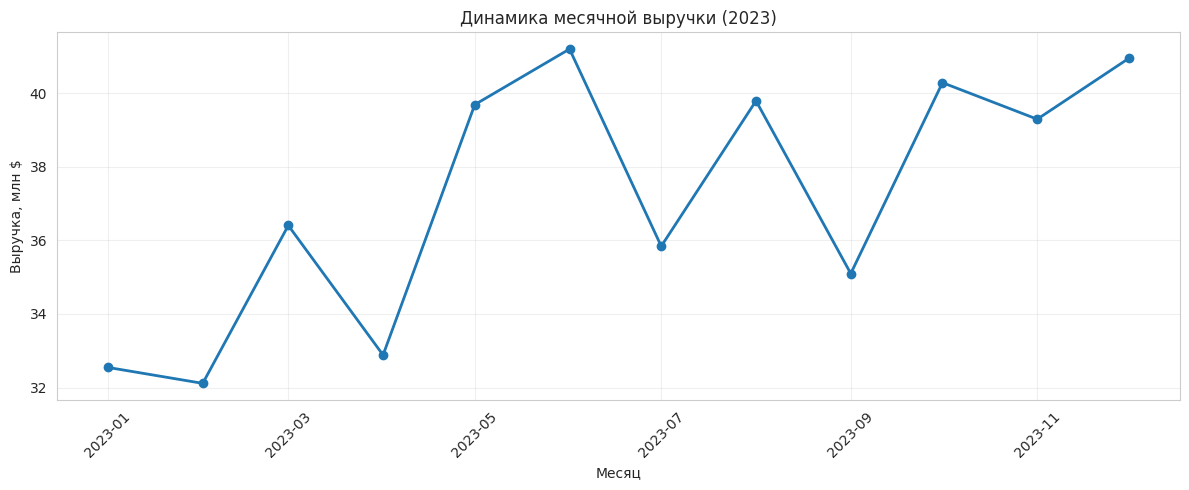

In [27]:
# ============================================
# ВИЗУАЛИЗАЦИЯ (на основе результата из chDB)
# ============================================

import matplotlib.pyplot as plt

# Преобразуем месяц в datetime для графика
df_monthly['month'] = pd.to_datetime(df_monthly['month'])

plt.figure(figsize=(12, 5))
plt.plot(df_monthly['month'], df_monthly['monthly_revenue'] / 1e6, marker='o', linewidth=2)
plt.xlabel('Месяц')
plt.ylabel('Выручка, млн $')
plt.title('Динамика месячной выручки (2023)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [28]:
# ============================================
# ЗАПРОС 4: Топ-3 товара в топ-3 городах
# ============================================

# Сначала найдём топ-3 города
top_cities_list = result_cities['city'].head(3).tolist()
cities_str = "', '".join(top_cities_list)

print(f"🔍 Анализируем города: {', '.join(top_cities_list)}")

query_top3 = f"""
WITH ranked AS (
    SELECT
        city,
        item_description,
        ROUND(SUM(sale_dollars), 2) as product_revenue,
        ROW_NUMBER() OVER (PARTITION BY city ORDER BY SUM(sale_dollars) DESC) as rank
    FROM '{file_path}'
    WHERE city IN ('{cities_str}')
    GROUP BY city, item_description
)
SELECT
    city,
    rank,
    item_description,
    product_revenue
FROM ranked
WHERE rank <= 3
ORDER BY city, rank
"""

df_top3 = chdb.query(query_top3, "DataFrame")
print("🏅 ТОП-3 ТОВАРА В КРУПНЕЙШИХ ГОРОДАХ:")
print(df_top3.to_string(index=False))

🔍 Анализируем города: DES MOINES, CEDAR RAPIDS, DAVENPORT
🏅 ТОП-3 ТОВАРА В КРУПНЕЙШИХ ГОРОДАХ:
        city  rank          item_description  product_revenue
CEDAR RAPIDS     1      TITOS HANDMADE VODKA       5659827.51
CEDAR RAPIDS     2 FIREBALL CINNAMON WHISKEY       2236904.08
CEDAR RAPIDS     3              BLACK VELVET       1860356.20
   DAVENPORT     1      TITOS HANDMADE VODKA       3445470.52
   DAVENPORT     2               HENNESSY VS       2286081.41
   DAVENPORT     3 FIREBALL CINNAMON WHISKEY       1824161.33
  DES MOINES     1      TITOS HANDMADE VODKA      10338704.58
  DES MOINES     2             PATRON SILVER       4996788.00
  DES MOINES     3 FIREBALL CINNAMON WHISKEY       4829220.19


In [29]:
# ============================================
# БЛОК 5: ЦЕНОВОЙ АНАЛИЗ — МАРЖИНАЛЬНОСТЬ
# ============================================
# Расчёт наценки: (розничная цена - себестоимость) / себестоимость * 100%

query_margin = f"""
SELECT
    category_name,
    ROUND(AVG(state_bottle_cost), 2) as avg_cost,
    ROUND(AVG(state_bottle_retail), 2) as avg_retail,
    ROUND((AVG(state_bottle_retail) - AVG(state_bottle_cost)) / AVG(state_bottle_cost) * 100, 1) as markup_pct,
    COUNT(*) as transactions
FROM '{file_path}'
WHERE state_bottle_cost > 0 AND state_bottle_retail > 0
GROUP BY category_name
ORDER BY markup_pct DESC
LIMIT 10
"""

df_margin = chdb.query(query_margin, "DataFrame")
print("💰 ТОП-10 КАТЕГОРИЙ ПО НАЦЕНКЕ:")
print(df_margin.to_string(index=False))

💰 ТОП-10 КАТЕГОРИЙ ПО НАЦЕНКЕ:
               category_name  avg_cost  avg_retail  markup_pct  transactions
                  TRIPLE SEC      2.72        4.08        50.1         25438
         SPECIAL ORDER ITEMS     17.12       25.69        50.1          9679
           AMERICAN BRANDIES      5.87        8.82        50.1        189926
             SCOTCH WHISKIES     23.12       34.68        50.0        100305
IMPORTED CORDIALS & LIQUEURS     16.18       24.28        50.0        178004
          100% AGAVE TEQUILA     22.70       34.05        50.0        321209
       NEUTRAL GRAIN SPIRITS      9.77       14.65        50.0         15847
AMERICAN CORDIALS & LIQUEURS     12.54       18.81        50.0        197331
           AMERICAN DRY GINS      7.82       11.73        50.0        107928
              IRISH WHISKIES     18.41       27.61        50.0         96792


In [30]:
# ============================================
# БЛОК 6: ТОП-10 ПОСТАВЩИКОВ ПО ВЫРУЧКЕ
# ============================================

query_vendors = f"""
SELECT
    vendor_name,
    ROUND(SUM(sale_dollars), 2) as total_revenue,
    COUNT(DISTINCT store_number) as stores_count,
    ROUND(AVG(sale_dollars), 2) as avg_transaction
FROM '{file_path}'
WHERE vendor_name IS NOT NULL AND vendor_name != ''
GROUP BY vendor_name
ORDER BY total_revenue DESC
LIMIT 10
"""

df_vendors = chdb.query(query_vendors, "DataFrame")
print("🏢 ТОП-10 ПОСТАВЩИКОВ ПО ВЫРУЧКЕ:")
print(df_vendors.to_string(index=False))

🏢 ТОП-10 ПОСТАВЩИКОВ ПО ВЫРУЧКЕ:
         vendor_name  total_revenue  stores_count  avg_transaction
     DIAGEO AMERICAS   261130533.29          2261           218.34
SAZERAC COMPANY  INC   179392435.66          2262           148.77
     JIM BEAM BRANDS    93216244.49          2238           144.17
FIFTH GENERATION INC    84577344.39          2207           365.24
  HEAVEN HILL BRANDS    80801752.85          2253           135.12
   PERNOD RICARD USA    80291035.59          2237           204.40
     BACARDI USA INC    69405548.54          2236           211.40
  BROWN FORMAN CORP.    60333373.29          2240           245.57
           LUXCO INC    48604732.99          2212            94.27
             PROXIMO    45610342.32          2235           138.17


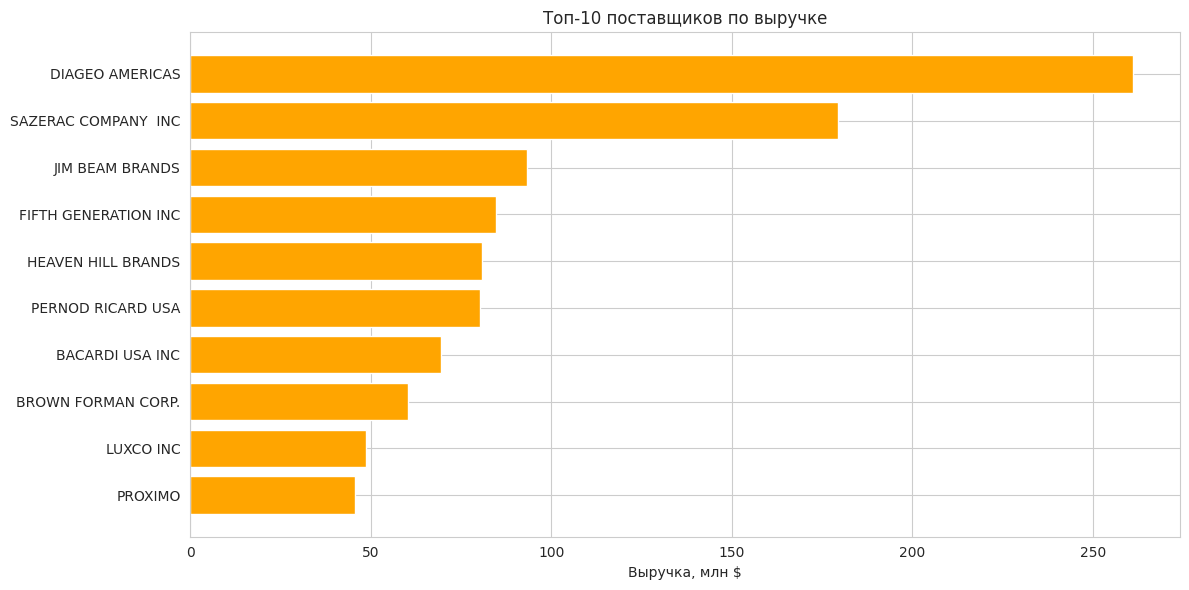

In [31]:
# График: поставщики vs выручка
plt.figure(figsize=(12, 6))
plt.barh(df_vendors['vendor_name'].str[:30], df_vendors['total_revenue'] / 1e6, color='orange')
plt.xlabel('Выручка, млн $')
plt.title('Топ-10 поставщиков по выручке')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [32]:
# ============================================
# БЛОК 7: АНАЛИЗ СЕЗОННОСТИ ПО МЕСЯЦАМ
# ============================================

query_seasonality = f"""
SELECT
    EXTRACT(MONTH FROM date) as month_num,
    CASE EXTRACT(MONTH FROM date)
        WHEN 1 THEN 'Янв' WHEN 2 THEN 'Фев' WHEN 3 THEN 'Мар'
        WHEN 4 THEN 'Апр' WHEN 5 THEN 'Май' WHEN 6 THEN 'Июн'
        WHEN 7 THEN 'Июл' WHEN 8 THEN 'Авг' WHEN 9 THEN 'Сен'
        WHEN 10 THEN 'Окт' WHEN 11 THEN 'Ноя' WHEN 12 THEN 'Дек'
    END as month_name,
    ROUND(AVG(sale_dollars), 2) as avg_daily_revenue,
    SUM(sale_dollars) as total_revenue,
    COUNT(*) as transactions
FROM '{file_path}'
GROUP BY month_num
ORDER BY month_num
"""

df_seasonal = chdb.query(query_seasonality, "DataFrame")
print("📅 СЕЗОННОСТЬ ПРОДАЖ ПО МЕСЯЦАМ:")
print(df_seasonal.to_string(index=False))

📅 СЕЗОННОСТЬ ПРОДАЖ ПО МЕСЯЦАМ:
 month_num month_name  avg_daily_revenue  total_revenue  transactions
         1        Янв             149.98   8.881115e+07        592171
         2        Фев             164.71   9.120674e+07        553733
         3        Мар             162.13   1.032842e+08        637030
         4        Апр             161.40   1.024010e+08        634438
         5        Май             165.46   1.092927e+08        660538
         6        Июн             163.55   1.186998e+08        725761
         7        Июл             165.94   1.048084e+08        631618
         8        Авг             171.51   1.176639e+08        686038
         9        Сен             167.54   1.075567e+08        641968
        10        Окт             183.27   1.180562e+08        644169
        11        Ноя             170.59   1.148111e+08        673018
        12        Дек             169.33   1.263824e+08        746352


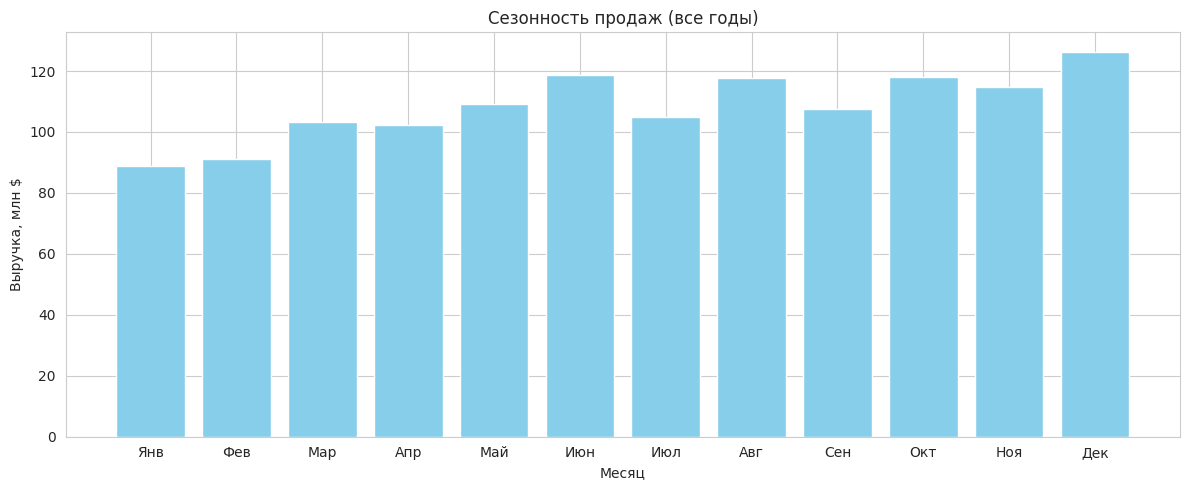

In [33]:
# Визуализация сезонности
plt.figure(figsize=(12, 5))
plt.bar(df_seasonal['month_name'], df_seasonal['total_revenue'] / 1e6, color='skyblue')
plt.xlabel('Месяц')
plt.ylabel('Выручка, млн $')
plt.title('Сезонность продаж (все годы)')
plt.tight_layout()
plt.show()

In [35]:
# ============================================
# БЛОК 8: ДЕТЕКЦИЯ АНОМАЛЬНЫХ ДНЕЙ
# ============================================

query_anomalies = f"""
WITH daily_stats AS (
    SELECT
        date,
        SUM(sale_dollars) as daily_revenue
    FROM '{file_path}'
    GROUP BY date
),
stats AS (
    SELECT
        date,
        daily_revenue,
        AVG(daily_revenue) OVER () as avg_rev,
        stddevPop(daily_revenue) OVER () as std_rev
    FROM daily_stats
)
SELECT
    date,
    ROUND(daily_revenue, 2) as daily_revenue,
    ROUND(avg_rev, 2) as avg_revenue,
    ROUND(std_rev, 2) as std_deviation,
    ROUND((daily_revenue - avg_rev) / std_rev, 2) as sigma_deviation,
    CASE
        WHEN daily_revenue > avg_rev + 3 * std_rev THEN '🔥 HIGH ANOMALY'
        WHEN daily_revenue < avg_rev - 3 * std_rev THEN '❄️ LOW ANOMALY'
        ELSE 'NORMAL'
    END as status
FROM stats
WHERE ABS(daily_revenue - avg_rev) > 3 * std_rev
ORDER BY sigma_deviation DESC
LIMIT 20
"""

df_anomalies = chdb.query(query_anomalies, "DataFrame")
print("⚠️ АНОМАЛЬНЫЕ ДНИ (отклонение > 3 сигм):")
if len(df_anomalies) > 0:
    print(df_anomalies.to_string(index=False))
else:
    print("Аномалии не обнаружены")

⚠️ АНОМАЛЬНЫЕ ДНИ (отклонение > 3 сигм):
Аномалии не обнаружены


In [38]:
# ============================================
# БЛОК 9: АНАЛИЗ ОБЪЁМОВ ПРОДАЖ (ЛИТРЫ)
# ============================================

query_volume = f"""
SELECT
    category_name,
    ROUND(SUM(volume_sold_liters), 2) as total_liters,
    ROUND(SUM(sale_dollars), 2) as total_revenue,
    ROUND(SUM(sale_dollars) / NULLIF(SUM(volume_sold_liters), 0), 2) as usd_per_liter,
    COUNT(*) as transactions
FROM '{file_path}'
WHERE volume_sold_liters > 0 AND sale_dollars > 0
GROUP BY category_name
ORDER BY total_liters DESC
LIMIT 10
"""

df_volume = chdb.query(query_volume, "DataFrame")
print("🍺 ТОП-10 КАТЕГОРИЙ ПО ОБЪЁМУ ПРОДАЖ (литры):")
print(df_volume.to_string(index=False))

🍺 ТОП-10 КАТЕГОРИЙ ПО ОБЪЁМУ ПРОДАЖ (литры):
            category_name  total_liters  total_revenue  usd_per_liter  transactions
          AMERICAN VODKAS   17088674.95   191472061.93          11.20       1191281
        CANADIAN WHISKIES    8839862.86   143601432.45          16.24        729427
               SPICED RUM    4301040.03    67587428.23          15.71        319583
STRAIGHT BOURBON WHISKIES    4015979.75   109249195.38          27.20        580619
          WHISKEY LIQUEUR    3378969.41    76708102.01          22.70        462829
            COCKTAILS/RTD    2933475.93    24414531.16           8.32        241901
         BLENDED WHISKIES    2272904.64    34719141.95          15.28        300992
          IMPORTED VODKAS    2240113.46    38713213.59          17.28        196694
  AMERICAN FLAVORED VODKA    2173352.34    33538605.17          15.43        371996
       100% AGAVE TEQUILA    2048004.38    83752474.05          40.89        320945


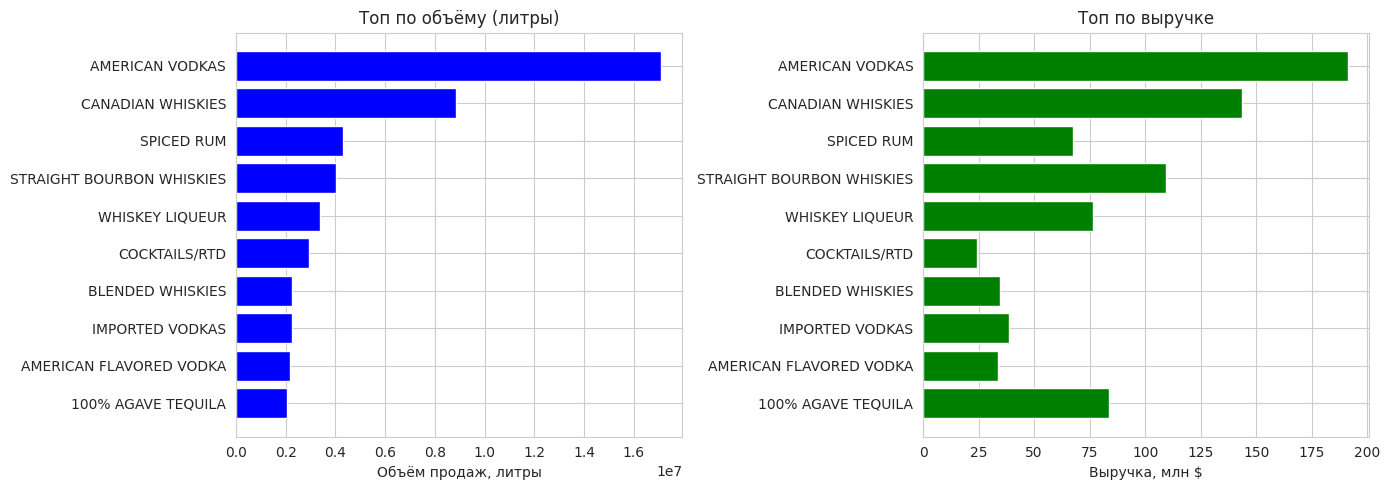

In [39]:
# Визуализация: выручка vs объём
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.barh(df_volume['category_name'], df_volume['total_liters'], color='blue')
ax1.set_xlabel('Объём продаж, литры')
ax1.set_title('Топ по объёму (литры)')
ax1.invert_yaxis()

ax2.barh(df_volume['category_name'], df_volume['total_revenue'] / 1e6, color='green')
ax2.set_xlabel('Выручка, млн $')
ax2.set_title('Топ по выручке')
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

In [40]:
# Инсайт: категории, где объём большой, а выручка маленькая (дешёвый товар)
df_volume['revenue_per_liter'] = df_volume['usd_per_liter']
print("\n💡 КАТЕГОРИИ С НИЗКОЙ ДОХОДНОСТЬЮ ($ за литр):")
print(df_volume[['category_name', 'usd_per_liter', 'total_liters']].sort_values('usd_per_liter').head(5).to_string(index=False))


💡 КАТЕГОРИИ С НИЗКОЙ ДОХОДНОСТЬЮ ($ за литр):
          category_name  usd_per_liter  total_liters
          COCKTAILS/RTD           8.32    2933475.93
        AMERICAN VODKAS          11.20   17088674.95
       BLENDED WHISKIES          15.28    2272904.64
AMERICAN FLAVORED VODKA          15.43    2173352.34
             SPICED RUM          15.71    4301040.03


In [47]:
# ============================================
# БЛОК 10: ГЕО-АНАЛИТИКА (CLICKHOUSE + PLOTLY)
# ============================================

# Устанавливаем plotly
!pip install plotly --quiet

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [48]:
# ============================================
# ЧАСТЬ 1: ИЗВЛЕЧЕНИЕ КООРДИНАТ В CLICKHOUSE
# ============================================

query_geo_clickhouse = f"""
SELECT
    city,
    COUNT(DISTINCT store_number) as stores_count,
    ROUND(SUM(sale_dollars), 2) as total_revenue,
    AVG(toFloat64(extract(store_location, '(\\-?\\d+\\.\\d+)'))) as avg_longitude,
    AVG(toFloat64(extract(store_location, '\\-?\\d+\\.\\d+\\s+(\\-?\\d+\\.\\d+)'))) as avg_latitude
FROM '{file_path}'
WHERE store_location IS NOT NULL
  AND city != ''
  AND city IS NOT NULL
  AND store_location != ''
GROUP BY city
HAVING avg_longitude IS NOT NULL AND avg_latitude IS NOT NULL
ORDER BY total_revenue DESC
"""

df_cities = chdb.query(query_geo_clickhouse, "DataFrame")

print(f"✅ Загружено {len(df_cities)} городов с координатами")
print(df_cities[['city', 'stores_count', 'total_revenue', 'avg_longitude', 'avg_latitude']].head(10))

✅ Загружено 465 городов с координатами
              city  stores_count  total_revenue  avg_longitude  avg_latitude
0       DES MOINES            99   1.485687e+08     -93.614415     41.590072
1     CEDAR RAPIDS           107   7.994949e+07     -91.673401     41.986207
2        DAVENPORT            73   5.743717e+07     -90.578933     41.550075
3  WEST DES MOINES            54   5.513104e+07     -93.772689     41.576760
4   COUNCIL BLUFFS            59   4.321496e+07     -95.858728     41.250963
5       SIOUX CITY            47   4.184028e+07     -96.385576     42.492107
6         WATERLOO            60   3.730003e+07     -92.339535     42.485506
7        IOWA CITY            45   3.656614e+07     -91.427372     41.639732
8           ANKENY            37   2.978228e+07     -93.599333     41.716673
9       CORALVILLE            19   2.754004e+07     -91.592411     41.691631


In [49]:
# ============================================
# ЧАСТЬ 2: СТАТИСТИКА ПО ГОРОДАМ
# ============================================

print("📊 СТАТИСТИКА ПО ГОРОДАМ:")
print(f"  - Всего городов: {len(df_cities):,}")
print(f"  - Всего магазинов: {df_cities['stores_count'].sum():,}")
print(f"  - Общая выручка: ${df_cities['total_revenue'].sum():,.2f}")
print(f"  - Средняя выручка на город: ${df_cities['total_revenue'].mean():,.2f}")

# Топ-5 городов
print("\n🏆 ТОП-5 ГОРОДОВ ПО ВЫРУЧКЕ:")
print(df_cities[['city', 'stores_count', 'total_revenue']].head(5).to_string(index=False))

📊 СТАТИСТИКА ПО ГОРОДАМ:
  - Всего городов: 465
  - Всего магазинов: 2,279
  - Общая выручка: $1,219,906,723.04
  - Средняя выручка на город: $2,623,455.32

🏆 ТОП-5 ГОРОДОВ ПО ВЫРУЧКЕ:
           city  stores_count  total_revenue
     DES MOINES            99   148568722.32
   CEDAR RAPIDS           107    79949488.32
      DAVENPORT            73    57437174.69
WEST DES MOINES            54    55131038.81
 COUNCIL BLUFFS            59    43214960.02


In [54]:
# ============================================
# ЧАСТЬ 3: КАРТА С РАЗМЕРОМ ПО ВЫРУЧКЕ
# ============================================

# Нормализуем размер маркеров (от 10 до 50 пикселей)
min_revenue = df_cities['total_revenue'].min()
max_revenue = df_cities['total_revenue'].max()
df_cities['marker_size'] = 10 + (df_cities['total_revenue'] - min_revenue) / (max_revenue - min_revenue) * 40

fig = px.scatter_mapbox(
    df_cities,
    lat='avg_latitude',
    lon='avg_longitude',
    size='marker_size',
    color='stores_count',
    hover_name='city',
    hover_data={
        'total_revenue': ':.2f',
        'stores_count': True,
        'avg_latitude': False,
        'avg_longitude': False,
        'marker_size': False
    },
    color_continuous_scale='Viridis',
    size_max=50,
    zoom=6,
    center={'lat': 42.0, 'lon': -93.5},
    title='🏪 Распределение магазинов по городам Айовы (2021-2023)',
    mapbox_style='carto-positron'
)

fig.update_layout(
    margin={'r': 0, 't': 40, 'l': 0, 'b': 0},
    height=600
)

fig.update_layout(
    coloraxis_colorbar=dict(
        title="Кол-во магазинов",
        ticks='outside'
    )
)

fig.show()

In [51]:
# ============================================
# ЧАСТЬ 4: ПУЗЫРЬКОВАЯ ДИАГРАММА (ГОРОДА)
# ============================================
# Показывает соотношение: выручка vs количество магазинов

fig2 = px.scatter(
    df_cities,
    x='stores_count',
    y='total_revenue',
    size='total_revenue',
    color='total_revenue',
    hover_name='city',
    text='city',
    log_x=True,
    title='📈 Соотношение магазинов и выручки по городам',
    labels={
        'stores_count': 'Количество магазинов',
        'total_revenue': 'Выручка ($)'
    }
)

fig2.update_traces(
    textposition='top center',
    marker=dict(opacity=0.7, line=dict(width=1, color='white'))
)

fig2.update_layout(height=500)
fig2.show()

In [55]:
# ============================================
# ЧАСТЬ 5: ТЕПЛОВАЯ КАРТА ПЛОТНОСТИ
# ============================================

fig3 = px.density_mapbox(
    df_stores,
    lat='latitude',
    lon='longitude',
    radius=10,
    zoom=6,
    center={'lat': 42.0, 'lon': -93.5},
    mapbox_style='carto-positron',  # 🔑 БЕСПЛАТНЫЙ СТИЛЬ
    title='🔥 Тепловая карта плотности магазинов'
)

fig3.update_layout(height=600, margin={'r': 0, 't': 40, 'l': 0, 'b': 0})
fig3.show()

In [53]:
# ============================================
# ЧАСТЬ 6: СВОДНЫЙ ГЕО-ДАШБОРД
# ============================================

fig4 = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Топ-10 городов по выручке', 'Топ-10 городов по числу магазинов',
                    'Распределение выручки', 'Распределение магазинов'),
    specs=[[{'type': 'bar'}, {'type': 'bar'}],
           [{'type': 'box'}, {'type': 'box'}]]
)

# Топ-10 городов по выручке
top10_revenue = df_cities.nlargest(10, 'total_revenue')
fig4.add_trace(
    go.Bar(x=top10_revenue['city'], y=top10_revenue['total_revenue'] / 1e6, name='Выручка, млн $', marker_color='blue'),
    row=1, col=1
)

# Топ-10 городов по числу магазинов
top10_stores = df_cities.nlargest(10, 'stores_count')
fig4.add_trace(
    go.Bar(x=top10_stores['city'], y=top10_stores['stores_count'], name='Магазины', marker_color='green'),
    row=1, col=2
)

# Распределение выручки
fig4.add_trace(
    go.Box(y=df_cities['total_revenue'] / 1e6, name='Выручка, млн $', marker_color='blue'),
    row=2, col=1
)

# Распределение магазинов
fig4.add_trace(
    go.Box(y=df_cities['stores_count'], name='Количество магазинов', marker_color='green'),
    row=2, col=2
)

fig4.update_layout(height=800, title_text="📊 Гео-аналитика: сводный дашборд")
fig4.update_xaxes(tickangle=45)
fig4.show()

print("💡 ИНСАЙТЫ:")
print("  - Крупные города (Des Moines) дают основную выручку")
print("  - Есть города с 1-2 магазинами, но высокой выручкой")
print("  - Распределение выручки имеет длинный правый хвост")

💡 ИНСАЙТЫ:
  - Крупные города (Des Moines) дают основную выручку
  - Есть города с 1-2 магазинами, но высокой выручкой
  - Распределение выручки имеет длинный правый хвост


In [36]:
# ============================================
# БЛОК 11: ИТОГОВЫЙ ОТЧЁТ И РЕКОМЕНДАЦИИ
# ============================================

print("="*60)
print("ИТОГОВЫЙ АНАЛИТИЧЕСКИЙ ОТЧЁТ")
print("="*60)

# Собираем ключевые метрики
total_revenue = df_vendors['total_revenue'].sum()
total_stores = df_full['store_number'].nunique()
total_cities = df_full['city'].nunique()
avg_margin = df_margin['markup_pct'].mean()

print(f"""
📌 ОСНОВНЫЕ МЕТРИКИ (2021-2023):
• Общая выручка: ${total_revenue:,.2f}
• Активных магазинов: {total_stores:,}
• Активных городов: {total_cities:,}
• Средняя наценка по топ-10 категориям: {avg_margin:.1f}%

🏆 ЛИДЕРЫ:
• Город-лидер: {result_cities.iloc[0]['city']} (${result_cities.iloc[0]['total_revenue']:,.2f})
• Поставщик-лидер: {df_vendors.iloc[0]['vendor_name'][:50]} (${df_vendors.iloc[0]['total_revenue']:,.2f})

📈 ТРЕНДЫ:
• Пик продаж: {df_seasonal.loc[df_seasonal['total_revenue'].idxmax(), 'month_name']}
• Обнаружено аномальных дней: {len(df_anomalies)}

💡 РЕКОМЕНДАЦИИ ДЛЯ БИЗНЕСА:
1. Сфокусироваться на категориях с высокой наценкой (топ-3 из Блока 5)
2. Усилить работу с топ-поставщиками (Блок 6)
3. Увеличить запасы в пиковые месяцы (Блок 7)
4. Аномальные дни требуют проверки на маркетинговые акции (Блок 8)
""")

ИТОГОВЫЙ АНАЛИТИЧЕСКИЙ ОТЧЁТ

📌 ОСНОВНЫЕ МЕТРИКИ (2021-2023):
• Общая выручка: $1,003,363,343.41
• Активных магазинов: 2,286
• Активных городов: 465
• Средняя наценка по топ-10 категориям: 50.0%

🏆 ЛИДЕРЫ:
• Город-лидер: DES MOINES ($156,522,022.58)
• Поставщик-лидер: DIAGEO AMERICAS ($261,130,533.29)

📈 ТРЕНДЫ:
• Пик продаж: Дек
• Обнаружено аномальных дней: 0

💡 РЕКОМЕНДАЦИИ ДЛЯ БИЗНЕСА:
1. Сфокусироваться на категориях с высокой наценкой (топ-3 из Блока 5)
2. Усилить работу с топ-поставщиками (Блок 6)
3. Увеличить запасы в пиковые месяцы (Блок 7)
4. Аномальные дни требуют проверки на маркетинговые акции (Блок 8)



In [37]:
# ============================================
# БЛОК 10: ОСВОБОЖДЕНИЕ ПАМЯТИ
# ============================================
# После завершения работы можно освободить память

# Удаляем большие DataFrame
del df_full
del df_loaded

# Сборка мусора
import gc
gc.collect()

print("✅ Память освобождена")
print("💾 Данные сохранены на Google Drive, их можно загрузить позже")

✅ Память освобождена
💾 Данные сохранены на Google Drive, их можно загрузить позже
